In [10]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(
    "../data/processed/credit_risk_features.csv"
)

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'income_loan_ratio', 'monthly_income', 'loan_income_ratio',
       'income_risk', 'loan_size_category', 'age_group', 'employment_category',
       'previous_default', 'high_debt_burden', 'high_interest_rate'],
      dtype='object')

In [5]:
#selecting features
features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
]

X = df[features]

y = df["loan_status"]

In [6]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
]

In [7]:
#numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [8]:
#categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [9]:
#combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [11]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 25928
Testing rows: 6483


In [12]:
#Model 1 - Logistic Regression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [13]:
#Model 2 - Random Forest

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [14]:
#train Logistic Regression
print("\nTraining Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)


Training Logistic Regression...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['person_age','person_income','person_home_ownership',...,'loan_amnt', 'loan_int_rate','loan_percent_income']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

In [15]:
#train random forest
print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

Training Random Forest...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['person_age','person_income','person_home_ownership',...,'loan_amnt', 'loan_int_rate','loan_percent_income']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

In [16]:
#predictions
logistic_pred = logistic_model.predict(X_test)

logistic_probability = logistic_model.predict_proba(
    X_test
)[:, 1]


rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [17]:
#evaluation metrics

def evaluate_model(name, y_true, predictions, probabilities):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions
    )

    recall = recall_score(
        y_true,
        predictions
    )

    f1 = f1_score(
        y_true,
        predictions
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    print("\n======================================")
    print(name)
    print("======================================")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_true,
            predictions
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            predictions
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [18]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_probability
)


rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_probability
)


Logistic Regression
Accuracy : 0.8129
Precision: 0.5517
Recall   : 0.7708
F1 Score : 0.6431
ROC-AUC  : 0.8687

Confusion Matrix:
[[4177  888]
 [ 325 1093]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5065
           1       0.55      0.77      0.64      1418

    accuracy                           0.81      6483
   macro avg       0.74      0.80      0.76      6483
weighted avg       0.85      0.81      0.82      6483


Random Forest
Accuracy : 0.9119
Precision: 0.8196
Recall   : 0.7659
F1 Score : 0.7918
ROC-AUC  : 0.9246

Confusion Matrix:
[[4826  239]
 [ 332 1086]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5065
           1       0.82      0.77      0.79      1418

    accuracy                           0.91      6483
   macro avg       0.88      0.86      0.87      6483
weighted avg       0.91      0.91      0.91  

In [19]:
results = pd.DataFrame(
    [
        logistic_results,
        rf_results
    ]
)

print("\n\nMODEL COMPARISON")
print("================")

print(
    results.round(4)
)



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8129     0.5517  0.7708    0.6431   0.8687
1        Random Forest    0.9119     0.8196  0.7659    0.7918   0.9246


In [20]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [21]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest_model.pkl"
)


print("\nModels saved successfully.")
print("Comparison saved successfully.")


Models saved successfully.
Comparison saved successfully.


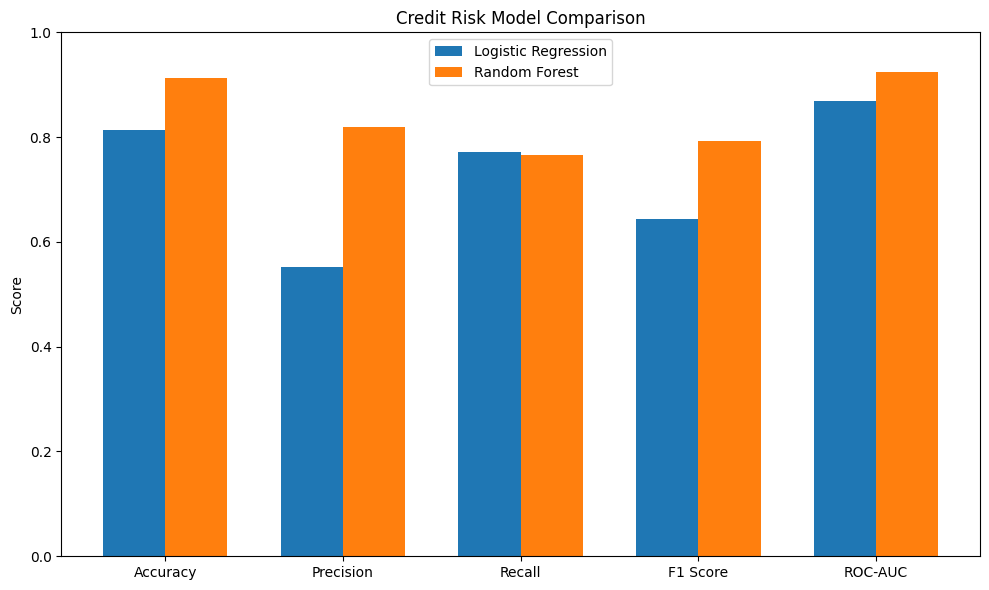

In [22]:
import matplotlib.pyplot as plt


# =========================================================
# MODEL COMPARISON CHART
# =========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    results.loc[0, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    results.loc[1, metrics],
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")

plt.title(
    "Credit Risk Model Comparison"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/model_comparison.png"
)

plt.show()